In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt


In [74]:
df=pd.read_csv(r'D:\mlproject\notebook\data\stud (1).csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [75]:
df.shape

(1000, 8)

In [76]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [77]:
df.dtypes

gender                         object
race_ethnicity                 object
parental_level_of_education    object
lunch                          object
test_preparation_course        object
math_score                      int64
reading_score                   int64
writing_score                   int64
dtype: object

In [78]:
df.isnull().sum() 

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

NO NULL VALUES , SO NO REPLACEMET OF NULL VAUES IS REQUIRED 

In [79]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

NO duplicates so no need to drop anyhting

In [80]:
# df.drop_duplicates()

In [81]:
print(df['race_ethnicity'].unique())
print(df['parental_level_of_education'].unique())

['group B' 'group C' 'group A' 'group D' 'group E']
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']


In [82]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [83]:
numerical_features=[feature for feature in df.columns if df[feature].dtype!='O']
cat_features=[feature for feature in df.columns if df[feature].dtype=='O']

print(f"there are total of {len(numerical_features)} numerical features and they   are {numerical_features} ")
print(f"there are total of {len(cat_features)} categorical  and they   are {cat_features} ")

there are total of 3 numerical features and they   are ['math_score', 'reading_score', 'writing_score'] 
there are total of 5 categorical  and they   are ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course'] 


In [84]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['average']=df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [85]:
# %%
import matplotlib.pyplot as plt
import seaborn as sns

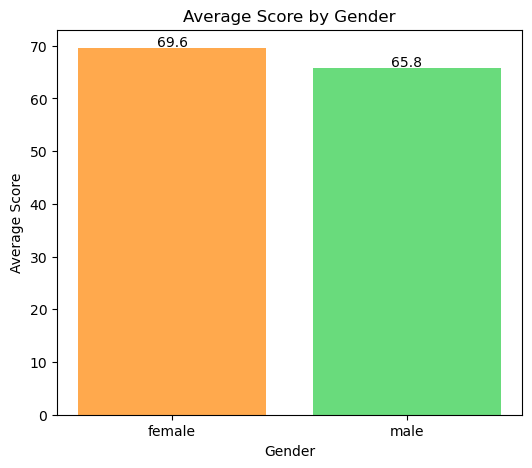

In [86]:
# %%
plt.figure(figsize=(6, 5))
gender_avg = df.groupby('gender')['average'].mean()
plt.bar(gender_avg.index, gender_avg.values, color=['#FFA94D', '#69DB7C'])
plt.title('Average Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Score')
for i, v in enumerate(gender_avg.values):
    plt.text(i, v + 0.3, f"{v:.1f}", ha='center')
plt.show()

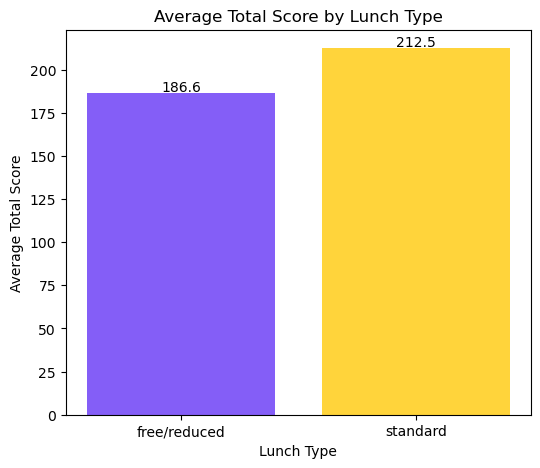

In [87]:
# %%
plt.figure(figsize=(6, 5))
lunch_total = df.groupby('lunch')['total_score'].mean()
plt.bar(lunch_total.index, lunch_total.values, color=['#845EF7', '#FFD43B'])
plt.title('Average Total Score by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Average Total Score')
for i, v in enumerate(lunch_total.values):
    plt.text(i, v + 1, f"{v:.1f}", ha='center')
plt.show()

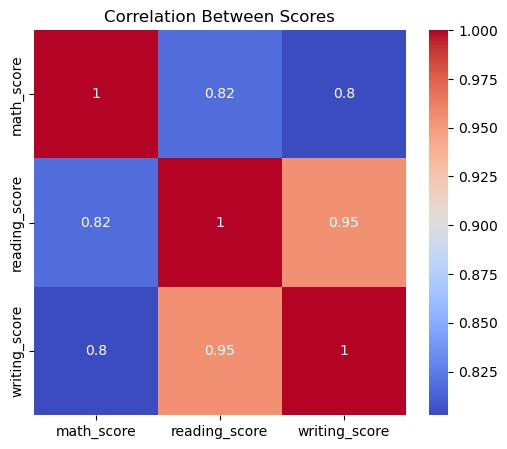

In [88]:
# %%
plt.figure(figsize=(6, 5))
sns.heatmap(df[['math_score', 'reading_score', 'writing_score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Scores')
plt.show()